In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [43]:
# ====== CONFIGURACIÓN ======
RUN_DIR = Path("experiments/carracing_ppo/run_20260424_113851_seed0")  # path al directorio de la corrida a analizar
SMOOTH_WINDOW = 50   # cantidad de episodios para la media móvil
USE_MOVING_AVERAGE = True

print("RUN_DIR =", RUN_DIR.resolve())
print("SMOOTH_WINDOW =", SMOOTH_WINDOW)

RUN_DIR = C:\Users\Jose\CEIA\Materias\Aprendizaje por Refuerzo I\Desafio\Codigo\ceia-ar1-desafio\car_racing\ppo\corridas\10_observation_resize\experiments\carracing_ppo\run_20260424_113851_seed0
SMOOTH_WINDOW = 50


In [44]:
def _read_monitor_csv(path: Path) -> pd.DataFrame:
    # Los archivos Monitor de Gymnasium/SB3 tienen una primera línea de metadata con '#'
    return pd.read_csv(path, comment="#")

def load_episode_data(run_dir: Path) -> tuple[pd.DataFrame, str]:
    vec_path = run_dir / "vec_monitor_train.csv"
    if vec_path.exists():
        df = _read_monitor_csv(vec_path)
        if {"r", "l", "t"}.issubset(df.columns):
            df = df.rename(columns={"r": "reward", "l": "length", "t": "time"})
            df["source"] = vec_path.name
            df["episode"] = np.arange(1, len(df) + 1)
            return df[["episode", "reward", "length", "time", "source"]], "vec_monitor_train.csv"

    monitor_files = sorted(run_dir.glob("monitor_train_*.csv"))
    if monitor_files:
        parts = []
        for f in monitor_files:
            part = _read_monitor_csv(f)
            if {"r", "l", "t"}.issubset(part.columns):
                part = part.rename(columns={"r": "reward", "l": "length", "t": "time"})
                part["source"] = f.name
                parts.append(part[["reward", "length", "time", "source"]])

        if parts:
            df = pd.concat(parts, ignore_index=True)
            df = df.sort_values(["time", "source"], kind="stable").reset_index(drop=True)
            df["episode"] = np.arange(1, len(df) + 1)
            return df[["episode", "reward", "length", "time", "source"]], "monitor_train_*.csv"

    raise FileNotFoundError(
        "No se encontró vec_monitor_train.csv ni monitor_train_*.csv en el folder de la corrida."
    )

episodes_df, source_used = load_episode_data(RUN_DIR)
print(f"Fuente usada: {source_used}")
print(f"Episodios cargados: {len(episodes_df)}")
episodes_df.head()

Fuente usada: monitor_train_*.csv
Episodios cargados: 1051


,episode,reward,length,time,source
0,1,-43.573668,1000,115.678967,monitor_train_0.csv.monitor.csv
1,2,-49.090909,1000,115.686954,monitor_train_1.csv.monitor.csv
2,3,-43.283582,1000,115.696965,monitor_train_2.csv.monitor.csv
3,4,-44.649446,1000,115.716847,monitor_train_3.csv.monitor.csv
4,5,-49.090909,1000,115.725758,monitor_train_4.csv.monitor.csv


In [45]:
episodes_df.describe(include="all")

,episode,reward,length,time,source
count,1051.00000,1051.000000,1051.000000,1051.000000,1051
unique,NaN,NaN,NaN,NaN,8
top,NaN,NaN,NaN,NaN,monitor_train_2.csv.monitor.csv
freq,NaN,NaN,NaN,NaN,135
mean,526.00000,569.248369,952.524263,9100.196748,NaN
std,303.54187,316.611262,120.320849,5216.794647,NaN
min,1.00000,-129.675000,256.000000,115.678967,NaN
25%,263.50000,312.811953,1000.000000,4630.471633,NaN
50%,526.00000,629.824561,1000.000000,8999.530732,NaN
75%,788.50000,871.377368,1000.000000,13635.226234,NaN


In [46]:
plot_df = episodes_df.copy()

if USE_MOVING_AVERAGE:
    plot_df["reward_smooth"] = (
        plot_df["reward"]
        .rolling(window=SMOOTH_WINDOW, min_periods=1)
        .mean()
    )
else:
    plot_df["reward_smooth"] = plot_df["reward"]

plot_df.head()

,episode,reward,length,time,source,reward_smooth
0,1,-43.573668,1000,115.678967,monitor_train_0.csv.monitor.csv,-43.573668
1,2,-49.090909,1000,115.686954,monitor_train_1.csv.monitor.csv,-46.332289
2,3,-43.283582,1000,115.696965,monitor_train_2.csv.monitor.csv,-45.316053
3,4,-44.649446,1000,115.716847,monitor_train_3.csv.monitor.csv,-45.149401
4,5,-49.090909,1000,115.725758,monitor_train_4.csv.monitor.csv,-45.937703


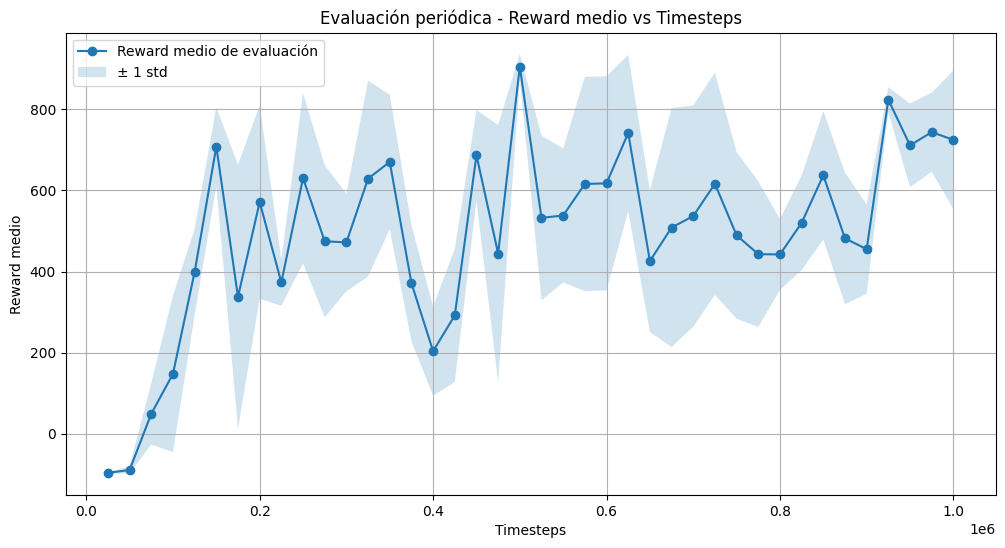

In [47]:
OUTPUT_PATH = RUN_DIR / "evaluacion_periodica_reward_medio_vs_timesteps.png"
eval_npz = RUN_DIR / "eval" / "evaluations.npz"
if eval_npz.exists():
    data = np.load(eval_npz)
    timesteps = data["timesteps"]
    results = data["results"]
    mean_rewards = results.mean(axis=1)
    std_rewards = results.std(axis=1)

    fig, ax = plt.subplots()
    ax.plot(timesteps, mean_rewards, marker="o", label="Reward medio de evaluación")
    ax.fill_between(
        timesteps,
        mean_rewards - std_rewards,
        mean_rewards + std_rewards,
        alpha=0.2,
        label="± 1 std",
    )
    ax.set_title("Evaluación periódica - Reward medio vs Timesteps")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Reward medio")
    ax.legend()
    fig.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No se encontró eval/evaluations.npz. Se omite este gráfico.")

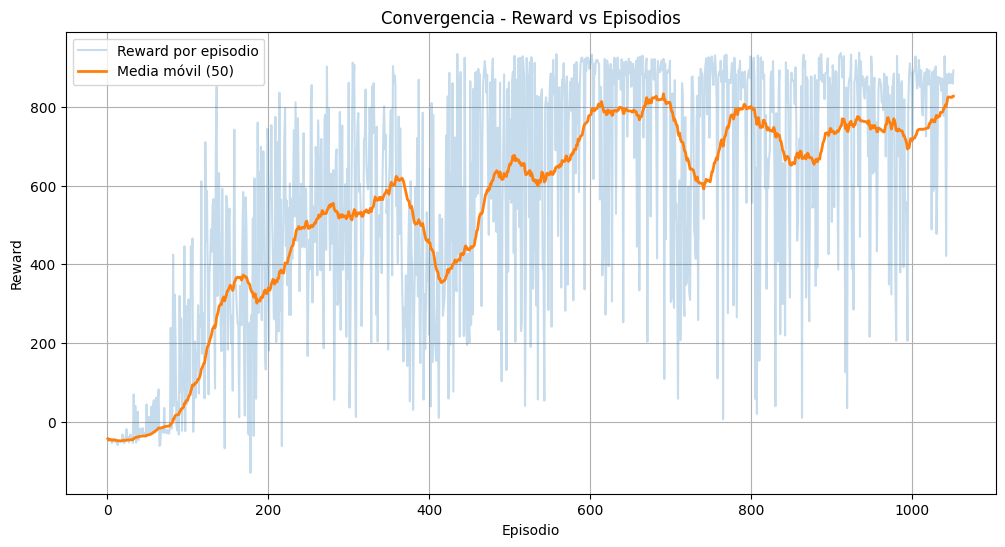

Gráfico guardado en: C:\Users\Jose\CEIA\Materias\Aprendizaje por Refuerzo I\Desafio\Codigo\ceia-ar1-desafio\car_racing\ppo\corridas\10_observation_resize\experiments\carracing_ppo\run_20260424_113851_seed0\convergencia_reward_vs_episodios.png


In [48]:
OUTPUT_PATH = RUN_DIR / "convergencia_reward_vs_episodios.png"

fig, ax = plt.subplots()
ax.plot(plot_df["episode"], plot_df["reward"], alpha=0.25, label="Reward por episodio")
ax.plot(
    plot_df["episode"],
    plot_df["reward_smooth"],
    linewidth=2,
    label=f"Media móvil ({SMOOTH_WINDOW})" if USE_MOVING_AVERAGE else "Reward",
)
ax.set_title("Convergencia - Reward vs Episodios")
ax.set_xlabel("Episodio")
ax.set_ylabel("Reward")
ax.legend()
fig.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado en: {OUTPUT_PATH.resolve()}")